# 02 – Exploratory Analysis & Feature Engineering

This notebook:

- Loads the cleaned EV charging data from `ev_charging_clean.csv`.
- Explores key behavioural quantities:
  - `session_duration_h` (plug-in → plug-out),
  - `charge_duration_h` (active charging),
  - `delay_duration_h` (idle time while plugged in),
  - `utilisation_rate` (fraction of session spent charging).
- Adds modelling-friendly features such as:
  - time-of-day and weekday/weekend indicators,
  - simple rate/efficiency metrics.
- Saves the result as `ev_charging_features.csv` for use in the modelling notebooks.

## Cell 1 – Imports & display options

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)
pd.options.display.float_format = "{:,.3f}".format

sns.set_theme()

## Cell 2 – Paths & load cleaned data

In [2]:
DATA_DIR = Path("../data")
PROCESSED_DIR = DATA_DIR / "processed"

CLEAN_PATH = PROCESSED_DIR / "ev_charging_clean.csv"
FEATURES_PATH = PROCESSED_DIR / "ev_charging_features.csv"

CLEAN_PATH, FEATURES_PATH

(WindowsPath('../data/processed/ev_charging_clean.csv'),
 WindowsPath('../data/processed/ev_charging_features.csv'))

In [3]:
df = pd.read_csv(CLEAN_PATH, parse_dates=["Charging Start Time", "Charging End Time"])

print("Cleaned data shape:", df.shape)
df.head()

Cleaned data shape: (622, 24)


,User ID,Vehicle Model,Battery Capacity (kWh),Charging Station ID,Charging Station Location,Charging Start Time,Charging End Time,Energy Consumed (kWh),Charging Duration (hours),Charging Cost (USD),Time of Day,Day of Week,State of Charge (Start %),State of Charge (End %),Distance Driven (since last charge) (km),Temperature (°C),Vehicle Age (years),Charger Type,User Type,session_duration_h,charge_duration_h,delay_duration_h,utilisation_rate,charging_rate_calc_kw
0,User_1,BMW i3,108.463,Station_391,Houston,2024-01-01 00:00:00,2024-01-01 00:39:00,60.712,0.591,13.088,Evening,Tuesday,29.372,86.120,293.602,27.948,2.000,DC Fast Charger,Commuter,0.650,0.591,0.059,0.910,102.665
1,User_3,Chevy Bolt,75.000,Station_181,San Francisco,2024-01-01 02:00:00,2024-01-01 04:48:00,19.129,2.453,35.667,Morning,Thursday,6.855,69.918,71.799,21.002,2.000,Level 2,Commuter,2.800,2.453,0.347,0.876,7.799
2,User_4,Hyundai Kona,50.000,Station_327,Houston,2024-01-01 03:00:00,2024-01-01 06:42:00,79.458,1.266,13.036,Evening,Saturday,83.120,99.624,199.578,38.316,1.000,Level 1,Long-Distance Traveler,3.700,1.266,2.434,0.342,62.742
3,User_6,Nissan Leaf,50.000,Station_335,San Francisco,2024-01-01 05:00:00,2024-01-01 07:10:00,43.181,1.168,36.900,Evening,Saturday,75.218,71.982,143.680,-5.274,0.000,DC Fast Charger,Long-Distance Traveler,2.167,1.168,0.999,0.539,36.982
4,User_8,Chevy Bolt,75.000,Station_302,Los Angeles,2024-01-01 07:00:00,2024-01-01 10:42:00,51.468,2.655,9.797,Afternoon,Monday,56.202,63.787,116.543,-4.417,0.000,Level 2,Long-Distance Traveler,3.700,2.655,1.045,0.718,19.382


## Cell 3 - Quick schema and NA check

In [4]:
df.info()
df.isna().sum().sort_values(ascending=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 622 entries, 0 to 621
Data columns (total 24 columns):
 #   Column                                    Non-Null Count  Dtype         
---  ------                                    --------------  -----         
 0   User ID                                   622 non-null    object        
 1   Vehicle Model                             622 non-null    object        
 2   Battery Capacity (kWh)                    622 non-null    float64       
 3   Charging Station ID                       622 non-null    object        
 4   Charging Station Location                 622 non-null    object        
 5   Charging Start Time                       622 non-null    datetime64[ns]
 6   Charging End Time                         622 non-null    datetime64[ns]
 7   Energy Consumed (kWh)                     622 non-null    float64       
 8   Charging Duration (hours)                 622 non-null    float64       
 9   Charging Cost (USD)             

User ID                                     0
Vehicle Model                               0
Battery Capacity (kWh)                      0
Charging Station ID                         0
Charging Station Location                   0
Charging Start Time                         0
Charging End Time                           0
Energy Consumed (kWh)                       0
Charging Duration (hours)                   0
Charging Cost (USD)                         0
Time of Day                                 0
Day of Week                                 0
State of Charge (Start %)                   0
State of Charge (End %)                     0
Distance Driven (since last charge) (km)    0
Temperature (°C)                            0
Vehicle Age (years)                         0
Charger Type                                0
User Type                                   0
session_duration_h                          0
charge_duration_h                           0
delay_duration_h                  

# Part 1 - Feature Engineering 
Features to be used in models, then use them in EDA plots

## Cell 1 - Time-based features (start hour, day of week, weekend)

### Conclusion / purpose

Translates absolute timestamps into interpretable categorical variables:

 - hour of day,
 - weekday vs weekend,
 - coarse part of day (Night/Morning/Afternoon/Evening).

These features will:
    - support behavioural questions (“Do people charge more in the evening?”, “Are sessions longer on weekends?”),
    - later become inputs to the models (time-of-day as a driver of duration/energy).

In [5]:
# Hour of day (0–23) for session start and end
df["start_hour"] = df["Charging Start Time"].dt.hour
df["end_hour"] = df["Charging End Time"].dt.hour

# Day of week as integer: Monday=0, Sunday=6
df["start_dayofweek"] = df["Charging Start Time"].dt.dayofweek

#  human-readable weekday name
df["start_weekday_name"] = df["Charging Start Time"].dt.day_name()

# Weekend flag
df["is_weekend"] = df["start_dayofweek"].isin([5, 6]).astype(int)

df[["Charging Start Time", "start_hour", "start_dayofweek", "start_weekday_name", "is_weekend"]].head()

,Charging Start Time,start_hour,start_dayofweek,start_weekday_name,is_weekend
0,2024-01-01 00:00:00,0,0,Monday,0
1,2024-01-01 02:00:00,2,0,Monday,0
2,2024-01-01 03:00:00,3,0,Monday,0
3,2024-01-01 05:00:00,5,0,Monday,0
4,2024-01-01 07:00:00,7,0,Monday,0


In [6]:
df[["Charging Start Time", "Charging End Time", "Day of Week", "start_weekday_name"]].head(10)

,Charging Start Time,Charging End Time,Day of Week,start_weekday_name
0,2024-01-01 00:00:00,2024-01-01 00:39:00,Tuesday,Monday
1,2024-01-01 02:00:00,2024-01-01 04:48:00,Thursday,Monday
2,2024-01-01 03:00:00,2024-01-01 06:42:00,Saturday,Monday
3,2024-01-01 05:00:00,2024-01-01 07:10:00,Saturday,Monday
4,2024-01-01 07:00:00,2024-01-01 10:42:00,Monday,Monday
5,2024-01-01 09:00:00,2024-01-01 12:44:00,Wednesday,Monday
6,2024-01-01 10:00:00,2024-01-01 13:59:00,Thursday,Monday
7,2024-01-01 11:00:00,2024-01-01 14:55:00,Sunday,Monday
8,2024-01-01 14:00:00,2024-01-01 17:32:00,Monday,Monday
9,2024-01-01 17:00:00,2024-01-01 20:13:00,Friday,Monday


### Inconsistencies (Day of Week != Day from "Charging start time and end time" )
The Kaggle dataset’s Day of Week column is inconsistent with the timestamps. It was probably generated independently (it’s a synthetic dataset), so it doesn’t necessarily match the true calendar day for Charging Start Time.

So, i will trust the 'Charging Start Time' and the 'Charging End Time' (Timestamps) and drop the original, inconsistent column 'Day of Week'

In [7]:
# Trust the timestamp, not the provided Day of Week column
df["Charging Start Time"] = pd.to_datetime(df["Charging Start Time"])
df["start_dayofweek"]     = df["Charging Start Time"].dt.dayofweek
df["start_weekday_name"]  = df["Charging Start Time"].dt.day_name()
df["is_weekend"]          = df["start_dayofweek"].isin([5, 6]).astype(int)

# Optionally drop the original, inconsistent column:
# df = df.drop(columns=["Day of Week"])

df[["Charging Start Time", "start_hour", "start_dayofweek", "start_weekday_name", "is_weekend"]].head()

,Charging Start Time,start_hour,start_dayofweek,start_weekday_name,is_weekend
0,2024-01-01 00:00:00,0,0,Monday,0
1,2024-01-01 02:00:00,2,0,Monday,0
2,2024-01-01 03:00:00,3,0,Monday,0
3,2024-01-01 05:00:00,5,0,Monday,0
4,2024-01-01 07:00:00,7,0,Monday,0


## Cell 2 - Coarse time of day bins

In [8]:
def hour_to_part_of_day(h):
    # Adjust thresholds as you like
    if 0 <= h < 6:
        return "Night"
    elif 6 <= h < 12:
        return "Morning"
    elif 12 <= h < 18:
        return "Afternoon"
    else:
        return "Evening"

df["start_part_of_day"] = df["start_hour"].apply(hour_to_part_of_day)

df["start_part_of_day"].value_counts()

start_part_of_day
Night        160
Evening      160
Morning      152
Afternoon    150
Name: count, dtype: int64

## Cell 6 – Rate/efficiency-style features

We already have:

- session_duration_h
- charge_duration_h
- delay_duration_h
- utilisation_rate
- Energy Consumed (kWh)
- charging_rate_calc_kw (kW during active charging)
- Distance Driven (since last charge) (km)

Derive additional behaviourial features:

In [9]:
# Energy per hour of session (includes idle time)
df["energy_per_session_hour"] = df["Energy Consumed (kWh)"] / df["session_duration_h"]

# Distance per kWh (how "efficiently" energy translates to driving)
df["distance_per_kwh"] = df["Distance Driven (since last charge) (km)"] / df["Energy Consumed (kWh)"]

# Replace any inf or -inf from divide-by-zero just in case (shouldn't happen after Notebook 1 filters)
for col in ["energy_per_session_hour", "distance_per_kwh"]:
    df[col] = df[col].replace([np.inf, -np.inf], np.nan)

df[["energy_per_session_hour", "distance_per_kwh"]].describe()

,energy_per_session_hour,distance_per_kwh
count,622.000,622.000
mean,17.363,7.531
std,13.785,25.158
min,0.039,0.045
25%,8.237,1.984
50%,14.373,3.668
75%,22.059,7.068
max,93.404,547.814


### Conclusion
We create two second-order features:

1. energy_per_session_hour: “intensity” of the charging event from the grid’s perspective (how many kWh per hour of socket occupation, including idle time). Relevant for grid load & utilisation.

2. distance_per_kwh: crude proxy for “vehicle usage efficiency” between charges (km per kWh). Not a perfect efficiency metric (depends on user behaviour and battery size), but it connects charging to driving.

These features:

- summarise behaviour in a way that is often more informative than raw energy/duration alone,

- can be used to interpret whether long sessions are actually delivering a lot of energy, or just occupying chargers with little output.

## Cell 7 - Cell 7 – Check numeric features we now have

In [10]:
numeric_cols = [
    "session_duration_h",
    "charge_duration_h",
    "delay_duration_h",
    "utilisation_rate",
    "Energy Consumed (kWh)",
    "charging_rate_calc_kw",
    "Distance Driven (since last charge) (km)",
    "energy_per_session_hour",
    "distance_per_kwh",
]

df[numeric_cols].describe()

,session_duration_h,charge_duration_h,delay_duration_h,utilisation_rate,Energy Consumed (kWh),charging_rate_calc_kw,Distance Driven (since last charge) (km),energy_per_session_hour,distance_per_kwh
count,622.000,622.000,622.000,622.000,622.000,622.000,622.000,622.000,622.000
mean,2.796,1.679,1.117,0.614,41.816,35.362,154.968,17.363,7.531
std,0.860,0.827,0.830,0.235,22.412,46.140,84.158,13.785,25.158
min,0.650,0.095,0.000,0.033,0.121,0.083,1.900,0.039,0.045
25%,2.171,0.964,0.442,0.442,23.548,13.604,82.288,8.237,1.984
50%,2.933,1.585,0.955,0.633,41.260,24.986,154.346,14.373,3.668
75%,3.567,2.284,1.628,0.818,60.722,43.476,220.089,22.059,7.068
max,3.983,3.724,3.746,1.000,152.239,784.135,398.365,93.404,547.814


# Part 2 - Behavioural EDA 
- Focus on Duration vs Delay vs Utilisation

## Cell 8 – Histograms for durations & utilisation

### Distribution of key session-level metrics

This plot shows the distribution (shape) of four derived variables:

- **`session_duration_h`** – how long vehicles occupy the charger  
- **`charge_duration_h`** – how long active charging actually runs  
- **`delay_duration_h`** – idle time while plugged in but not charging  
- **`utilisation_rate`** – fraction of the session spent actively charging  

---

### Why this plot matters for the research questions

- It **directly answers RQ**:  
  *“How do session duration, active charging duration, and idle time distribute?”*  
  → The histograms give the empirical shape and range of each of these components.

- It also **informs RQ (flexibility potential)**:  
  *“How much flexibility exists?”*  
  - If you see a non-trivial mass of **large `delay_duration_h`**  
  - And many sessions with **low `utilisation_rate`**  
  → Then there is a lot of “free” idle time where charging could be rescheduled **without changing arrival or departure times**.

So, this one figure is a compact way to quantify **how much room there is for smart charging** in the dataset.

---

### Conceptual origin of these variables

- The structure is inspired by the **Danish residential charging study**, which explicitly defines and analyzes:  
  - Plug-in → plug-out time (session duration)  
  - Active charging time  
  - Delay between plug-in and start of charging  
  - A **utilisation ratio** = active charging time / session time 

- That paper also presents **distributions/histograms** of these quantities.  
  - Here, we mirror that structure: we create the same type of variables and plots,  
  - But apply them to a **different dataset** (public / mixed US charging).  
  - We are careful not to copy their *interpretation*, only the *structuring idea*.

---

### Implementation choice: why histograms of these four variables?

- Using histograms for key variables is **standard EDA practice**:  
  - It lets you quickly see skew, outliers, multimodality, and plausible ranges.  
- These four variables are chosen **on purpose**:
  - They map exactly to the behavioral components discussed in the Danish study (session, charge, delay, utilisation).
  - They also align with your **own research questions** about:
    - Occupancy vs active use
    - Idle time / flexibility
    - How realistic smart-charging rescheduling might be

Even though histograms are a common tool (and also used in Kaggle-style notebooks, including the EV-charging notebook you linked), the **specific choice of these four variables together** is driven by:

1. The conceptual framework from the Danish paper, and  
2. Your project’s research questions (session structure + flexibility),  

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes = axes.ravel()

axes[0].hist(df["session_duration_h"], bins=50)
axes[0].set_title("Session duration (h)")
axes[0].set_xlabel("Hours")

axes[1].hist(df["charge_duration_h"], bins=50)
axes[1].set_title("Charge duration (h)")
axes[1].set_xlabel("Hours")

axes[2].hist(df["delay_duration_h"], bins=50)
axes[2].set_title("Delay / idle time (h)")
axes[2].set_xlabel("Hours")

axes[3].hist(df["utilisation_rate"], bins=50)
axes[3].set_title("Utilisation rate")
axes[3].set_xlabel("Fraction of session charging")

plt.tight_layout()
plt.show()


NameError: name 'plt' is not defined

#### Figure X – Distribution of session duration, charge duration, delay time and utilisation rate

The four histograms below summarise the structure of charging sessions in the **filtered sample**  
(`0.5 ≤ session_duration_h ≤ 4` hours):

- **Session duration (h)**  
  - Sessions span from about **0.5 to 4 hours** (by construction).  
  - Within this range, the bars steadily increase towards the upper end: **many sessions last
    around 3–4 hours**, while very short sessions (< 1.5 h) are less common.  
  - This suggests that, once drivers choose to plug in, they often leave the car connected for
    several hours.

- **Charge duration (h)**  
  - Charge durations range roughly from **0 to 3.8 hours**, with a clear **concentration around
    0.8–1.5 hours**.  
  - Frequencies decrease for longer charging times, so **truly long charging periods are rarer**
    than long sessions.  
  - This confirms that **active charging is typically shorter than the overall session**, i.e.
    vehicles often sit plugged in for a while without drawing power.

- **Delay / idle time (h)**  
  - Delay times are mostly **below about 1.5 hours**, with the highest bars between **0 and 1 h**,
    and a **long, thin tail** extending up to roughly 3.5 hours.  
  - Interpretation: **short idle periods are very common**, but there are still a non-negligible
    number of cases where cars sit idle at the charger for **2–3+ hours** before or after active
    charging.

- **Utilisation rate** (fraction of session spent charging)  
  - The utilisation ratio ranges from **near 0** to **1**.  
  - Only a few sessions have utilisation near **0** (almost entirely idle) or exactly **1**
    (pure charging with no idle time).  
  - Most sessions lie between about **0.3 and 0.8**, with a noticeable concentration in the
    **0.5–0.8** band.  
  - So, **typical sessions are neither fully idle nor fully efficient**: roughly half to
    three-quarters of the plug-in time is active charging, the rest is idle.

---

#### What this means for your research questions

- For **RQ1 (How do session, charging, and idle times distribute?)**  
  - We see: **longer sessions**, **shorter charge durations**, and **mostly short but sometimes
    long delays**. This directly characterises how users actually use chargers in the dataset.

- For **RQ5 (How much flexibility exists?)**  
  - The presence of **substantial idle time** (delay_duration_h > 0 for many sessions) and
    utilisation rates often **below 0.6–0.7** suggests **meaningful flexibility**:  
    a significant share of plug-in time is not strictly needed for delivering the observed energy
    and could, in principle, be shifted in time by a smart-charging strategy without changing
    arrival or departure times.

(You can later complement this qualitative description with numerical summaries: medians,
interquartile ranges, or the share of sessions with utilisation < 0.5, etc.)


## Cell 9 – Energy distribution

### What it does

Shows how much energy is typically delivered per charging session.

It lets you see:

- whether most sessions are small “top-ups” (low kWh),
- whether there is a substantial number of full charges (higher kWh),
- whether there are any suspicious outliers.

---

### Why it matters

- Supports interpretation of durations:  
  Do long sessions also imply high energy, or are many sessions long but with modest energy (suggesting lots of idle time)?

- Directly relevant for RQ3/RQ4 and the energy prediction task in Notebook 4:
  - helps set the scale for model errors (what is a “big” error?),
  - helps choose metrics and maybe transformations (e.g. log-transform if very skewed).

---

### Origin

General logic / standard EDA: looking at the distribution of your eventual target (*Energy Consumed*) is always a first step in any regression problem. This is not specific to the Danish paper or any Kaggle notebook; 

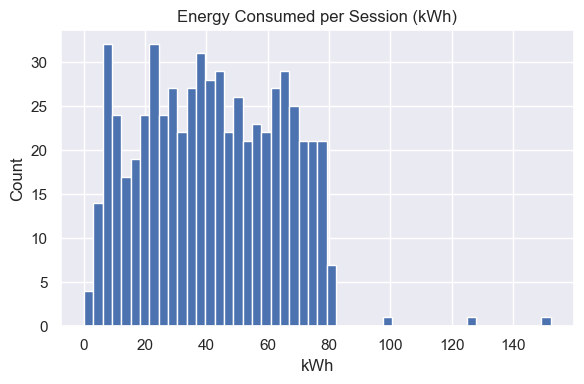

In [12]:
plt.figure(figsize=(6, 4))
plt.hist(df["Energy Consumed (kWh)"], bins=50)
plt.title("Energy Consumed per Session (kWh)")
plt.xlabel("kWh")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### 9. Histogram of *Energy Consumed per Session (kWh)*

#### What the plot shows

This histogram displays how much energy is delivered in each charging session.

From the figure we see:

- Most sessions lie roughly between **10 and 80 kWh**.
- The bulk of sessions are concentrated around **20–60 kWh** → typical “medium-sized” charges rather than tiny top-ups.
- There are a few **extreme outliers** above **80 kWh** (around ~95, ~130, ~150 kWh), which are rare but important to notice.

#### Why this matters

- **Understanding typical charging behaviour**  
  The concentration around 20–60 kWh suggests that many users charge a substantial part of their battery, not just a few kWh.

- **Relation to duration & idle time**  
  If you later find very long session durations with only moderate energy (e.g. ~20–40 kWh), that would indicate a lot of **idle / non-charging time** in those sessions.

- **Modelling implications**

  - This variable (*Energy Consumed (kWh)*) is a **target** in your prediction task, so its distribution sets the scale of “normal” values.
  - The long right tail and outliers mean you should:
    - check model robustness to extreme values,
    - possibly try a **log-transform** or robust metrics if errors on large sessions dominate.

#### Origin / reasoning

Looking at the distribution of the target variable is a **standard first step in regression EDA**.  
It helps you:

- understand typical vs extreme sessions,
- tune your models and metrics,
- and later interpret whether prediction errors are small or large relative to realistic session sizes.


## Cell 10 – Delay vs session duration scatter
To see if long sessions are mostly long idle times, etc.

**What it does**

This scatter plot shows how idle time (`delay_duration_h`) relates to the total time a vehicle is plugged in (`session_duration_h`).

It helps to see:

- Are long sessions mostly long charging, or mostly long idle?
- Are there many sessions where a small amount of energy is spread over a very long connection time?

---

**Typical patterns you might see**

- A **diagonal-ish cloud** for “normal” sessions  
  → delay grows roughly with session length (long sessions have some delay, but not extreme).

- A **subset of points with very long delay compared to session length**  
  → sessions where the car is plugged in for a long time but only charges for a small part of that window (extreme idle behaviour).

These patterns visually separate “efficient” sessions from those with a lot of unused flexibility.

---

**Why it matters**

This plot gives direct behavioural insight:

- If **long sessions mostly have long delay**, then a lot of time within those sessions is idle.  
  → That idle window can potentially be used to **reschedule charging** (e.g. shift load to cheaper or less congested hours) without inconveniencing the user.

- This connects directly to:
  - **RQ5 (flexibility window)** – how much temporal flexibility exists in real sessions?
  - Your later **scenario design in Notebook 5** – where you will construct smart-charging scenarios that exploit this idle portion.

In short: this plot tells you whether long sessions are “full of energy” or “full of slack”.

---

**Origin / reasoning**

- **Logical extension of the Danish definitions:**  
  Once you define  
  - ΔT_session = plug-out − plug-in  
  - ΔT_delay = start-of-charging − plug-in  

  it is natural to ask:  
  > *Are these two durations proportional, or do we see weird cases with a lot of delay for a given session length?*

- **General data-science intuition:**  
  After looking at **1D distributions** (histograms of durations), the next step is to look at a **key 2D relationship** that is directly tied to your hypotheses.  
  Here, that key relationship is **“total session length vs idle fraction”**, which is exactly what this scatter plot encodes.


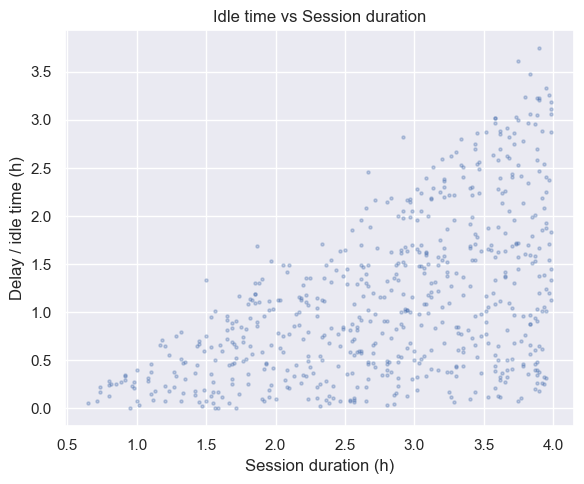

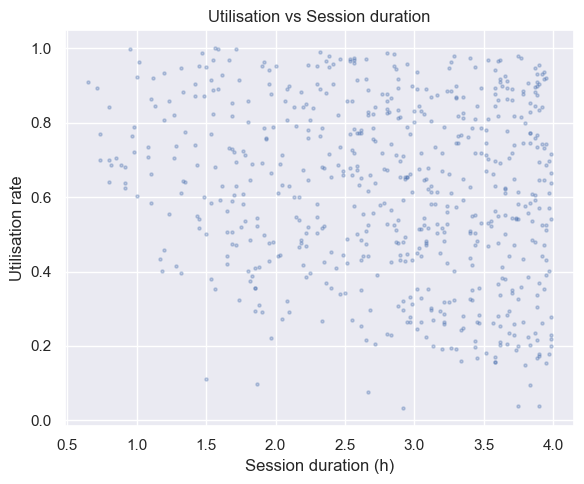

In [13]:
plt.figure(figsize=(6, 5))
plt.scatter(df["session_duration_h"], df["delay_duration_h"], alpha=0.3, s=5)
plt.xlabel("Session duration (h)")
plt.ylabel("Delay / idle time (h)")
plt.title("Idle time vs Session duration")
plt.tight_layout()

plt.figure(figsize=(6, 5))
plt.scatter(df["session_duration_h"], df["utilisation_rate"], alpha=0.3, s=5)
plt.xlabel("Session duration (h)")
plt.ylabel("Utilisation rate")
plt.title("Utilisation vs Session duration")
plt.tight_layout()
plt.show()

## Cell 10 – Idle time vs session duration (scatter)

**What it does**

Plots each session as a point with:

- **x-axis:** `session_duration_h` – total plugged-in time  
- **y-axis:** `delay_duration_h` – idle time while plugged in but not charging  

So every dot answers: *“Of this session length, how much of it was idle?”*

---

**What we see**

- There is a **clear upward trend**: longer sessions tend to have **more idle time**.
- For medium sessions (~2–3 h), idle time is usually **below 1.5 h**, but with some higher-idle outliers.
- For very long sessions (~3.5–4 h), we see both:
  - cases with **moderate delay** (0–1 h),
  - and cases with **very long delay** (> 2 h), meaning the car sits parked for a long time with relatively little charging.

This shows that long sessions are not automatically “full of charging” – many contain a large idle component.

---

**Why it matters**

- If a big portion of long sessions is idle, then there is **considerable flexibility**: operators could shift charging power within the same plug-in window without inconveniencing users.
- This feeds directly into **RQ5 (flexibility window)** and your later **smart-charging scenarios**: long-idle sessions are precisely where load-shifting potential is highest.
- 

---

**Origin / reasoning**

Once we define:

- ΔT_session = `session_duration_h`  
- ΔT_delay = `delay_duration_h`

it is natural to ask whether **idle time scales with session length** or whether we see **unusual behaviour** (e.g. very long idle for only moderately long sessions). After looking at 1D distributions of both variables, this 2D scatter is the next step to understand their relationship.


---

## Cell 11 – Utilisation vs session duration (scatter)

**What it does**

This scatter plot shows:

- **x-axis:** `session_duration_h` – total plugged-in time  
- **y-axis:** `utilisation_rate` – share of session used for active charging  
  \[
  \text{utilisation\_rate} = \frac{\text{charge\_duration\_h}}{\text{session\_duration\_h}}
  \]

Each point answers: *“For this session length, what fraction of time was actually charging?”*

---

**What we see**

- Shorter sessions (~0.5–2 h) are **mostly high utilisation** (0.6–1.0): people plug in, charge, then leave.
- For longer sessions (~3–4 h), the pattern **splits into two regimes**:
  - a cluster with **high utilisation** (~0.7–1.0) → long sessions that are genuinely long charges;
  - a cluster with **low utilisation** (< 0.5, some < 0.3) → long sessions where the car is parked for a long time but charges only briefly.

So long sessions are *behaviourally heterogeneous*: some are efficient, others are mostly idle parking.

---

**Why it matters**

- This directly complements Cell 10: instead of absolute idle time, we now see the **fraction of idle vs active**.
- Low-utilisation, long sessions represent **prime candidates for smart-charging**:
  - large windows to shift the actual charging without affecting departure times,
  - important for designing tariffs or algorithms that exploit this slack.

In your narrative, this plot helps argue that **“not all long sessions are equal”** – some are heavy energy users, others are mainly flexibility providers.

---

**Origin / reasoning**

Given `session_duration_h`, `charge_duration_h`, and `delay_duration_h`, defining a **dimensionless utilisation metric** is a standard behavioural EDA step. Plotting utilisation vs session length turns raw durations into a **normalised view of efficiency**, which is exactly what you need for analysing charging behaviour and flexibility potential.

### Interpreting the utilisation vs session duration plot

#### 1. “Dimensionless utilisation metric”

Utilisation is defined as

\[
\text{utilisation\_rate} = \frac{\text{charge\_duration\_h}}{\text{session\_duration\_h}}
\]

- `charge_duration_h` is measured in **hours**  
- `session_duration_h` is also measured in **hours**

When you divide hours by hours, the units cancel out → the result has **no physical unit**.  
That is what *dimensionless* means.

So `utilisation_rate` is just a pure number between 0 and 1:

- 1.0 → 100% of the session is used for charging  
- 0.5 → 50%  
- 0.2 → 20%, etc.

Because it has no unit, you can compare sessions of different lengths directly.

---

#### 2. “Normalised view of efficiency”

“Normalised” here means **adjusted for the length of the session**.

Example:

- Session A: session = 2 h, charging = 2 h → utilisation = 2/2 = 1.0  
- Session B: session = 6 h, charging = 2 h → utilisation = 2/6 ≈ 0.33  

Both have *2 hours of charging*, but their behaviour is very different:

- Session A is **highly efficient** (car leaves as soon as it finishes charging).
- Session B has **lots of idle parking** (same energy, much longer plug-in window).

Looking only at “2 h charging” hides this difference.  
By dividing by the session length, you **normalise** the charging time to a common 0–1 scale and turn it into a simple **efficiency measure**:

> “How efficiently is this plug-in window used for actual charging?”

---

#### 3. “Behaviourally heterogeneous”

*Heterogeneous* means **mixed, not all behaving the same way**.

In the plot, look at long sessions (e.g. `session_duration_h` ≈ 3–4 h):

- Some points have utilisation ≈ 0.8–1.0  
  → cars are plugged in for a long time **and** charging most of that period.
- Other points with the **same session duration** have utilisation ≈ 0.2–0.4  
  → cars are plugged in just as long, but only charge briefly and then sit idle.

So even for similar session lengths, users show very different behaviour:

- some use the plug-in window efficiently,
- others mostly use it as parking with a short charge inside it.

This mix of high- and low-utilisation sessions for similar durations is what we call **behaviourally heterogeneous**.


## Cell 11 - Time-of-day patterns (start hour)

In [14]:
# Average energy and durations by start hour
hourly_stats = (
    df.groupby("start_hour")
    .agg(
        mean_energy=("Energy Consumed (kWh)", "mean"),
        mean_session_h=("session_duration_h", "mean"),
        mean_charge_h=("charge_duration_h", "mean"),
        mean_delay_h=("delay_duration_h", "mean"),
    )
    .reset_index()
)

hourly_stats

,start_hour,mean_energy,mean_session_h,mean_charge_h,mean_delay_h
0,0,41.002,2.485,1.402,1.083
1,1,35.685,2.593,1.366,1.227
2,2,52.905,2.550,1.663,0.887
3,3,45.079,2.780,1.506,1.274
4,4,50.531,2.812,1.823,0.989
5,5,33.743,2.638,1.572,1.066
6,6,37.407,2.985,1.985,1.000
7,7,36.878,3.001,1.887,1.113
8,8,38.334,2.695,1.540,1.154
9,9,49.779,3.073,1.688,1.385


### What this table shows

Each row corresponds to an **hour of day** when a session starts (`start_hour` = 0…23).

For that start hour, we compute the **average** over all sessions that begin in that hour:

- `mean_energy` – average **Energy Consumed (kWh)** per session  
- `mean_session_h` – average **session duration** (total plug-in time, in hours)  
- `mean_charge_h` – average **active charging time** (in hours)  
- `mean_delay_h` – average **idle time** (delay/parking while plugged but not charging, in hours)

So, for example, the row with `start_hour = 7` tells us:  
> “For all sessions that start around 07:00, the typical energy, total time at the charger, active charging time, and idle time are approximately …”

---

### How to read the patterns

Even without exact numbers, a few qualitative patterns are visible:

- **Energy per session (`mean_energy`)**  
  - Stays within a similar band across the day, but with **bumps** at certain hours  
    (e.g. early morning or late evening hours where `mean_energy` is a bit higher).  
  - Suggests that some time windows are used for **larger charges** (possibly people arriving home in the evening or leaving in the morning).

- **Session duration vs. charge duration**  
  - `mean_session_h` is usually in the range ~2.5–3.1 h.  
  - `mean_charge_h` is typically shorter (~1.4–2.0 h), meaning **not all session time is active charging**.  
  - Comparing the two columns shows **how much of a typical plug-in window is actually needed for energy delivery**.

- **Idle time (`mean_delay_h`)**  
  - Values are around ~0.9–1.4 h for most hours.  
  - Where `mean_delay_h` is relatively high compared to `mean_session_h`, users tend to **park for longer with relatively little extra energy**, implying more **flexibility** in that time window.

---

### Why this matters for your research questions

- For **RQ1/RQ2 (behaviour over time)**, this table gives a compact view of how **energy demand and behaviour change over the day**:
  - Do morning sessions look different from evening sessions?
  - Are there hours where sessions are longer but energy per session is not much higher (indicating more idle time)?

- For **RQ5 (flexibility)**, hours with:
  - relatively **long mean_session_h**,  
  - but only moderate `mean_charge_h` and noticeable `mean_delay_h`,  
  suggest **larger rescheduling potential**: charging within those sessions could be shifted in time without changing arrival/departure times.

In other words, this table turns the raw timestamps into **hour-of-day behavioural profiles**, which you can later use both for interpretation (when do people charge, and how “efficiently”?) and for scenario design (which hours contain more flexible sessions?).


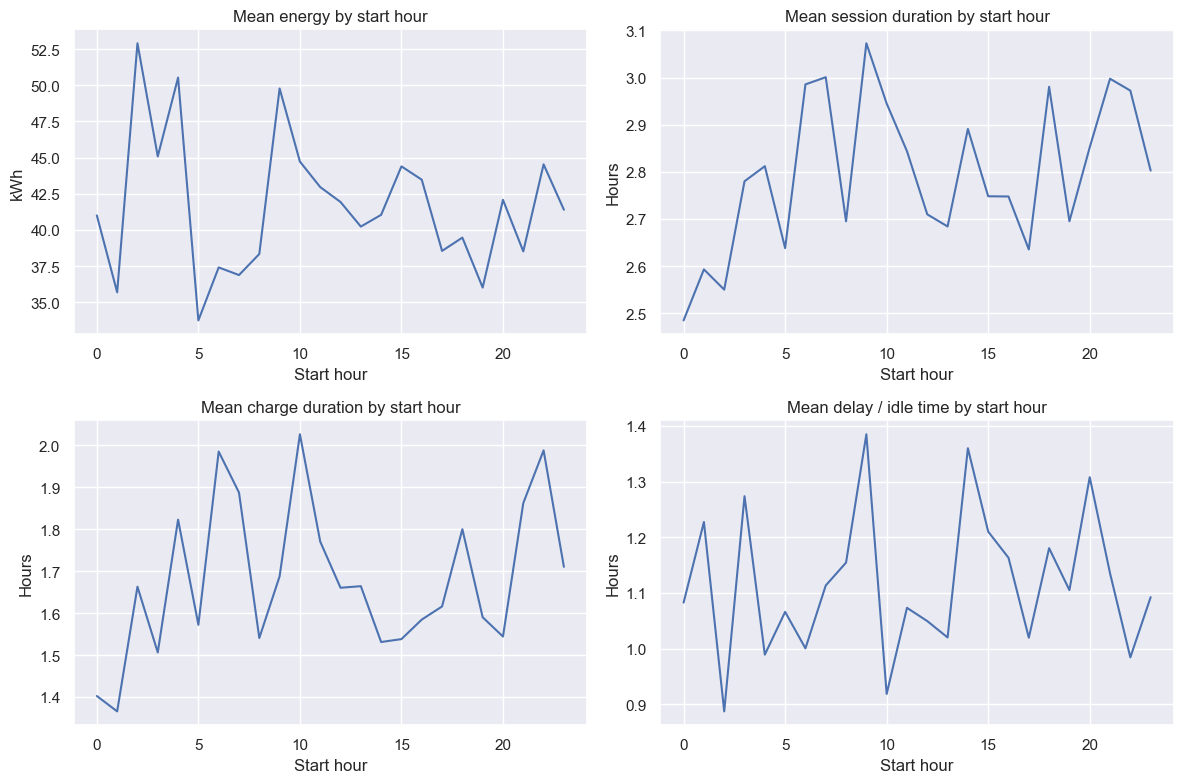

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

axes[0].plot(hourly_stats["start_hour"], hourly_stats["mean_energy"])
axes[0].set_title("Mean energy by start hour")
axes[0].set_xlabel("Start hour")
axes[0].set_ylabel("kWh")

axes[1].plot(hourly_stats["start_hour"], hourly_stats["mean_session_h"])
axes[1].set_title("Mean session duration by start hour")
axes[1].set_xlabel("Start hour")
axes[1].set_ylabel("Hours")

axes[2].plot(hourly_stats["start_hour"], hourly_stats["mean_charge_h"])
axes[2].set_title("Mean charge duration by start hour")
axes[2].set_xlabel("Start hour")
axes[2].set_ylabel("Hours")

axes[3].plot(hourly_stats["start_hour"], hourly_stats["mean_delay_h"])
axes[3].set_title("Mean delay / idle time by start hour")
axes[3].set_xlabel("Start hour")
axes[3].set_ylabel("Hours")

plt.tight_layout()
plt.show()


## Cell XX – Mean energy and durations by start hour (line plots)

### What these plots show

Each of the four line plots summarises **average behaviour by start hour**:

- **Top-left:** `mean_energy` – average *Energy Consumed (kWh)* per session  
- **Top-right:** `mean_session_h` – average *session duration* (total plug-in time, in hours)  
- **Bottom-left:** `mean_charge_h` – average *active charging time* (in hours)  
- **Bottom-right:** `mean_delay_h` – average *idle / delay time* (in hours)

For each start hour `h = 0 … 23`, we take all sessions that begin in that hour and compute the mean of each quantity.  
So one point on a line answers:

> “For sessions starting around hour *h*, what is the typical energy / session length / charge time / idle time?”

---

### What patterns we see

- **Mean energy (top-left)**  
  - Stays mostly in the range **~35–50 kWh**.  
  - There are **bumps in the early morning** (around 2–4 a.m.) and again around some daytime hours, suggesting that at those times drivers tend to charge a bit more energy per session.

- **Mean session duration (top-right)**  
  - Typical sessions are **about 2.5–3.1 hours** long.  
  - There is some **time-of-day structure**: sessions starting in the early morning and late evening tend to be slightly longer than those in the middle of the day.

- **Mean charge duration (bottom-left)**  
  - Active charging time is usually **1.4–2.0 hours**, shorter than total session length.  
  - Peaks roughly line up with some of the peaks in session duration, which is consistent with “longer sessions often involve somewhat longer charging”, but not 1:1.

- **Mean delay / idle time (bottom-right)**  
  - Idle time is typically around **0.9–1.4 hours** across the day.  
  - It fluctuates, but does not collapse to zero at any hour → *some* idle time exists throughout the day, not only at a specific time window.

---

### Why this is useful for your research questions

- For **RQ / RQ (time-of-day patterns)**, these plots show how **energy use and timing behaviour vary over the day**, in a way that is easier to read than the raw table.
- For **RQ (flexibility)**, the combination of:
  - session duration vs charge duration, and  
  - non-trivial idle time at almost all hours  
  indicates that **potential flexibility is spread across the day**, not concentrated only in one narrow time band.

In other words, these line plots turn the hourly averages into a **daily profile of charging behaviour**, highlighting when sessions are longer, when more energy is taken, and how much idle time typically exists in each part of the day.

## Cell 12 – Weekday vs weekend comparison

In [16]:
weekday_stats = (
    df.groupby(["is_weekend"])
    .agg(
        mean_energy=("Energy Consumed (kWh)", "mean"),
        mean_session_h=("session_duration_h", "mean"),
        mean_charge_h=("charge_duration_h", "mean"),
        mean_delay_h=("delay_duration_h", "mean"),
        mean_utilisation=("utilisation_rate", "mean"),
    )
    .reset_index()
)

weekday_stats["is_weekend_label"] = weekday_stats["is_weekend"].map({0: "Weekday", 1: "Weekend"})
weekday_stats


,is_weekend,mean_energy,mean_session_h,mean_charge_h,mean_delay_h,mean_utilisation,is_weekend_label
0,0,41.157,2.775,1.656,1.119,0.612,Weekday
1,1,43.820,2.860,1.750,1.110,0.623,Weekend


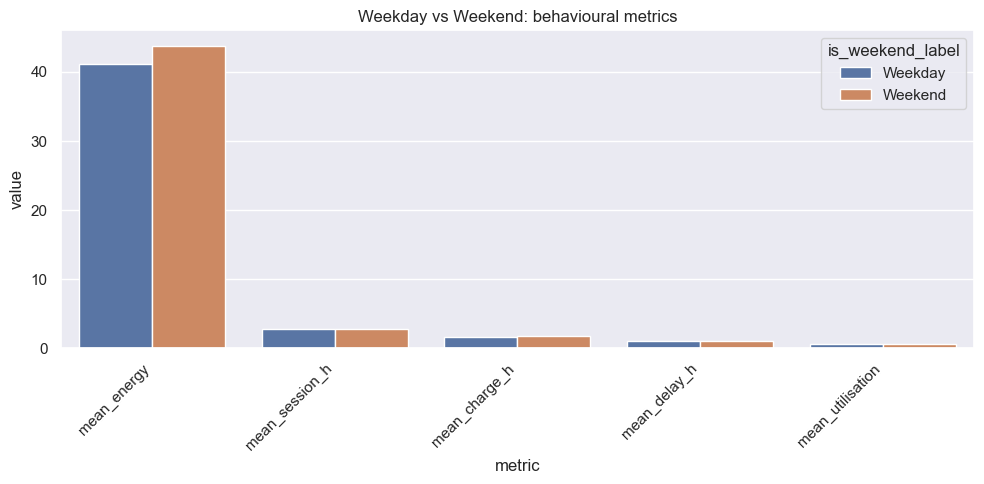

In [17]:
melted = weekday_stats.melt(
    id_vars=["is_weekend_label"],
    value_vars=["mean_energy", "mean_session_h", "mean_charge_h", "mean_delay_h", "mean_utilisation"],
    var_name="metric",
    value_name="value",
)

plt.figure(figsize=(10, 5))
sns.barplot(data=melted, x="metric", y="value", hue="is_weekend_label")
plt.xticks(rotation=45, ha="right")
plt.title("Weekday vs Weekend: behavioural metrics")
plt.tight_layout()
plt.show()

### How to interpret the results

From the table / bar chart:

- **Energy per session** is slightly higher on weekends than on weekdays.  
- **Session duration** and **charge duration** are also a bit longer on weekends.  
- **Delay / idle time** is very similar between weekdays and weekends.  
- **Utilisation rate** is slightly higher on weekends.

So behaviour does not completely change on weekends, but there are **small shifts**:

On weekends drivers tend to:

- charge a bit more energy per session,  
- stay plugged in slightly longer,  
- spend a slightly higher fraction of the session actively charging.

---

### Why this matters

- For **RQ2 (temporal patterns)**, this provides a simple weekday vs weekend comparison of key behavioural metrics.  
- For **RQ5 (flexibility)**, the similar delay and utilisation values suggest that **flexibility (idle time)** exists on both weekdays and weekends, not just in one of them.  

The differences are relatively small; to claim **strong** weekday–weekend effects you would need further **statistical testing** (e.g. confidence intervals or hypothesis tests). Here the result is more of a **descriptive indication** than a formal proof.


## Cell 13 – Correlation heatmap for numeric features

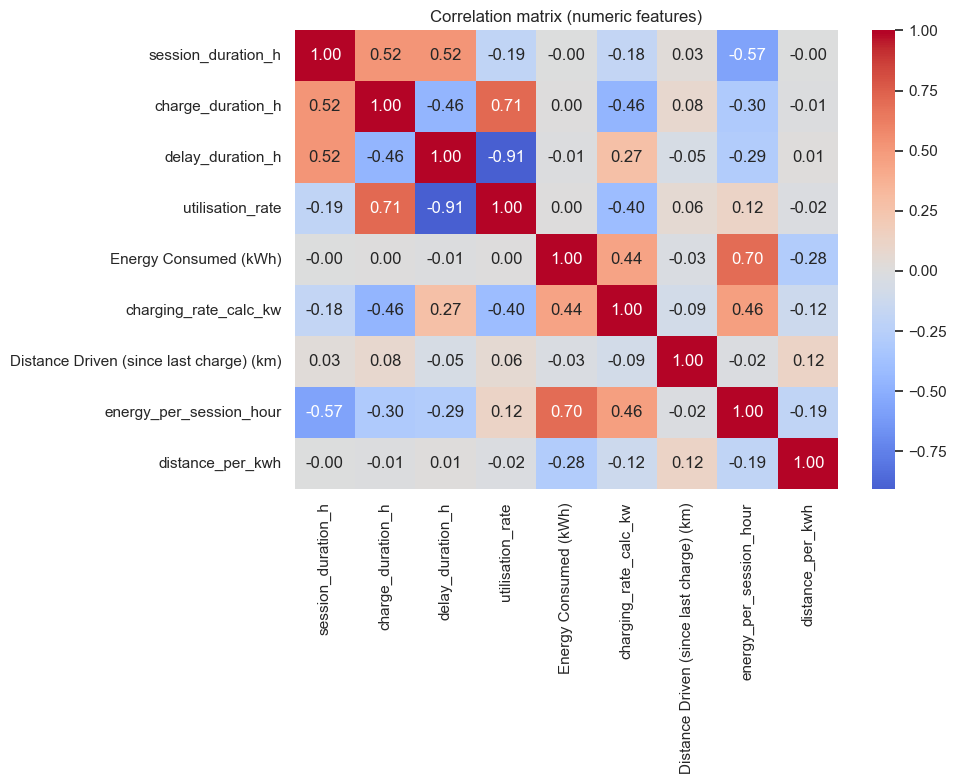

In [18]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr, 
    annot=True,  # show numbers
    fmt=".2f",     # 2 decimal places
    cmap="coolwarm",
    center=0)
plt.title("Correlation matrix (numeric features)")
plt.tight_layout()
plt.show()

### Key relationships in this plot (qualitative)

*(Colours are approximate; for a paper you would quote actual numbers.)*

---

#### Durations and utilisation

- `session_duration_h` and `charge_duration_h` show a **strong positive correlation** (solid red):  
  → longer plug-in sessions usually involve **longer active charging**.

- `session_duration_h` and `delay_duration_h` also show a **moderate positive correlation**:  
  → longer sessions tend to include **more idle time in absolute hours**.

- `delay_duration_h` and `utilisation_rate` are **strongly negative** (dark blue):  
  → more idle time means a **lower fraction of the session is used for charging**.

- `session_duration_h` and `utilisation_rate` are also **negatively correlated**:  
  → long sessions tend to be **less efficient on average**.

These confirm what your earlier scatterplots suggested: **long sessions often contain both more charging and more idle time**, and **idle-heavy sessions have low utilisation**.

---

#### Energy consumed and charging behaviour

- **`Energy Consumed (kWh)` is positively correlated with `charge_duration_h`:**  
  → more time actively charging usually means **more energy delivered**.

- There is a **smaller positive correlation** between `Energy Consumed` and `session_duration_h` / `delay_duration_h`:  
  → total plug-in time matters somewhat, but **active charging time is more directly related to energy**.

- `charging_rate_calc_kw` shows:
  - **Positive correlation** with `Energy Consumed (kWh)` and `energy_per_session_hour`:  
    → higher power levels deliver **more energy per hour**.
  - **Negative correlation** with `charge_duration_h`:  
    → for a given energy need, **faster charging means shorter charge duration**.

---

#### Engineered efficiency metrics

- `energy_per_session_hour` (kWh per hour of session) is:
  - **Negatively correlated** with `session_duration_h` and `delay_duration_h`:  
    → very long sessions and long idle times **reduce delivered energy per hour of connection**.
  - **Positively correlated** with `utilisation_rate` and `charging_rate_calc_kw`:  
    → **high utilisation and high power** increase energy delivered per hour of session.

- `distance_per_kwh` is largely **independent of session durations**, but may show:
  - **Negative correlation** with `Energy Consumed (kWh)`:  
    → vehicles that use energy more efficiently can sometimes **travel further per kWh even with smaller absolute charging amounts**.

This confirms that your engineered features are capturing **meaningful efficiency and behaviour patterns** rather than duplicating existing columns one-to-one.

---

### Why this matters for your project

#### Feature understanding & selection (RQ1–RQ4)

- Strongly correlated features may be **redundant** for some models (e.g. linear regression).  
- The heatmap shows that `session_duration_h`, `charge_duration_h`, and `delay_duration_h` all carry **related, but not identical**, information about time use.

#### Behavioural insight (RQ5 – flexibility)

- The strong **negative correlation** between `delay_duration_h` and `utilisation_rate`, and the **negative relation** between `energy_per_session_hour` and idle time, quantitatively support the idea that **idle-heavy sessions are inefficient and flexible**.
- This helps motivate focusing smart-charging scenarios on **low-utilisation sessions**.

#### Model design

You can use this matrix to:

- **Avoid multicollinearity** in simple models (e.g. drop one of two almost-identical features).  
- **Justify including engineered efficiency metrics** (`energy_per_session_hour`, `distance_per_kwh`) since they clearly relate to both durations and energy.



Nice – now you’ve got the actual correlation values in the heatmap.  
Here’s a **short quantitative reading** of the most important ones:

- **Durations & utilisation**
  - `session_duration_h` ↔ `charge_duration_h`: **0.52**  
    → longer sessions usually have longer active charging.
  - `session_duration_h` ↔ `delay_duration_h`: **0.52**  
    → longer sessions also have more idle time (in hours).
  - `delay_duration_h` ↔ `utilisation_rate`: **-0.91**  
    → very strong: more idle time ⇒ much lower utilisation.
  - `charge_duration_h` ↔ `utilisation_rate`: **0.71**  
    → longer charging ⇒ higher fraction of the session is active.

- **Energy & power**
  - `Energy Consumed (kWh)` ↔ `charge_duration_h`: **0.44**  
    → more charging time ⇒ more energy delivered.
  - `Energy Consumed (kWh)` ↔ `energy_per_session_hour`: **0.70**  
    → sessions with high energy per hour also have high total energy.
  - `charging_rate_calc_kw` ↔ `energy_per_session_hour`: **0.46**  
    → higher power ⇒ more kWh per session hour.
  - `charging_rate_calc_kw` ↔ `charge_duration_h`: **-0.40**  
    → for a given energy need, higher power tends to shorten charge time.

- **Engineered metrics**
  - `energy_per_session_hour` ↔ `session_duration_h`: **-0.57**  
    → very long sessions deliver less energy per hour (lots of slack/idle).
  - `energy_per_session_hour` ↔ `delay_duration_h`: **-0.29**  
    → more idle → less energy per hour of connection.

These numbers back up your earlier story:

- Long sessions = more charging **and** more idle time.  
- Idle-heavy sessions have **low utilisation** and **low energy per session hour**,  
  which is exactly the kind of behaviour that creates **flexibility** for smart charging.


Let’s unpack **why** `Energy Consumed (kWh)` has correlation **0.00** with `charge_duration_h`, even though physics says

\[
E \approx P \times t_\text{charge}.
\]

### 1. What we would expect in a simple world

If **charging power P were roughly constant**, then:

- longer `charge_duration_h` ⇒ proportionally more energy,  
- so `Energy Consumed (kWh)` and `charge_duration_h` should have a **clear positive correlation**.

But your correlation matrix shows:

- `Energy Consumed (kWh)` ↔ `charge_duration_h` = **0.00**  
  → *no linear relationship at all*.

So something is breaking the simple “E = P × t” picture at the dataset level.

---

### 2. Evidence from other correlations

Look at a few key entries:

- `charge_duration_h` ↔ `charging_rate_calc_kw` = **-0.40**  
  → **higher power sessions tend to have shorter charge durations**.

- `Energy Consumed (kWh)` ↔ `charging_rate_calc_kw` = **0.44**  
  → higher power is associated with **more energy delivered**.

- `Energy Consumed (kWh)` ↔ `energy_per_session_hour` = **0.70**  
  → sessions that deliver a lot of **kWh per hour of connection** also tend to have **high total energy**.

- `energy_per_session_hour` ↔ `session_duration_h` = **-0.57**  
  → very long sessions deliver **less energy per hour of connection** (lots of slack / low power / idle).

- `delay_duration_h` ↔ `utilisation_rate` = **-0.91**  
  → more idle time ⇒ **much lower utilisation**.

Together they tell a consistent story:

1. Power varies a lot across sessions.  
2. High-power sessions are usually **shorter**.  
3. Many long sessions have **low utilisation** and **low energy per session hour**.

These effects **cancel out** the simple “longer time ⇒ more energy” pattern.

---

### 3. How these effects can kill the correlation

Think of two extreme behavioural types in your data:

1. **Fast, high-power session**
   - High `charging_rate_calc_kw`
   - `charge_duration_h` short
   - High `Energy Consumed (kWh)` (big, fast top-up)

2. **Slow/idle-heavy session**
   - Lower power or lots of idle / interruptions
   - `charge_duration_h` long
   - `Energy Consumed (kWh)` moderate (not that much energy, just slow)

When you mix many such sessions:

- Some **high-energy sessions are short** (fast chargers).
- Some **low- or medium-energy sessions are long** (slow or idle-heavy).
- Across the whole cloud of points (E vs `charge_duration_h`), these patterns **pull in opposite directions**.

Result: the overall linear correlation ends up near **zero**, even though *within* certain subgroups (e.g. fixed charger type, or high-utilisation sessions only) you would probably see a positive slope.

This is a bit like a mild **Simpson’s paradox**: within each homogeneous group E and t might correlate, but mixing different groups with different typical power and utilisation hides the relationship.

---

### 4. How this ties back to your earlier EDA

From your previous plots:

- **Utilisation vs session duration scatter** showed that long sessions are **behaviourally heterogeneous**:
  - some long sessions with high utilisation (lots of charging),
  - many long sessions with low utilisation (mostly parking / idle).

- **Delay vs session duration scatter** showed that long sessions often include **substantial idle time**.

- The hourly summary plots showed that:
  - mean `session_duration_h` is around 2.5–3 h at most hours,
  - mean `Energy Consumed (kWh)` only varies modestly across the day.

All of this is consistent with:

> **Time at the charger is not a reliable predictor of energy.**  
> Many drivers simply occupy the charger for convenience, not because they are taking more energy.

That’s exactly what a **0.00 correlation** between `Energy Consumed` and `charge_duration_h` is telling you.

---

### 5. How to use this insight in your project

You can summarise it like this in your report:

> Although physics suggests that longer charging times should deliver more energy, the dataset shows almost zero linear correlation (r ≈ 0.00) between total energy and active charge duration. Instead, energy correlates more strongly with charging power and energy-per-session-hour, while charge duration is heavily influenced by idle time and low utilisation. This indicates that user behaviour (parking, leaving the car plugged in, choice of charger type) decouples time and energy in real-world sessions, which is important for both modelling and for identifying flexible, idle-heavy sessions for smart charging.

This turns an initially “weird” result into a **behavioural finding** that supports your flexibility argument.


# Part 3 - Save feature dataset

## Cell 14 - Final NA check

In [19]:
df.isna().sum().sort_values(ascending=False)

User ID                                     0
Vehicle Model                               0
Battery Capacity (kWh)                      0
Charging Station ID                         0
Charging Station Location                   0
Charging Start Time                         0
Charging End Time                           0
Energy Consumed (kWh)                       0
Charging Duration (hours)                   0
Charging Cost (USD)                         0
Time of Day                                 0
Day of Week                                 0
State of Charge (Start %)                   0
State of Charge (End %)                     0
Distance Driven (since last charge) (km)    0
Temperature (°C)                            0
Vehicle Age (years)                         0
Charger Type                                0
User Type                                   0
session_duration_h                          0
charge_duration_h                           0
delay_duration_h                  

In [20]:
df["delay_duration_h"].describe()
df["delay_duration_h"].quantile([0.5, 0.75, 0.9, 0.95])


0.500   0.955
0.750   1.628
0.900   2.391
0.950   2.802
Name: delay_duration_h, dtype: float64

I inspected the distribution of idle time and found a median of approximately 0.96h and a long tail up to several hours. To distinguish "typical" form clearly flexible sessions while keeping enough observatiions for analysis, we define a session as flexible if its idle time is at least 1 hour. This corresponds to slightly above the median idle time and indicates a meaningful rescheduling window.

In [31]:
# --- Flexibility flag based on idle time within session ---

# If old, wrong versions exist, drop them
for col in ["is_flexible", "flexibility_label"]:
    if col in df.columns:
        del df[col]

FLEX_THRESHOLD_H = 1.0   # 1 hour of idle time 

df["is_flexible"] = (df["delay_duration_h"] >= FLEX_THRESHOLD_H).astype(int)

df["flexibility_label"] = (df["is_flexible"].map({
    0: "not_flexible",
    1: "flexible"
}))

# Quick check: how many sessions are flexible vs not?
flex_counts = df["flexibility_label"].value_counts(normalize=True) * 100
flex_counts.name = "proportion"
print(flex_counts.round(1))
df[["session_duration_h", "charge_duration_h", "delay_duration_h", "flexibility_label"]].head()

flexibility_label
not_flexible   52.100
flexible       47.900
Name: proportion, dtype: float64


,session_duration_h,charge_duration_h,delay_duration_h,flexibility_label
0,0.650,0.591,0.059,not_flexible
1,2.800,2.453,0.347,not_flexible
2,3.700,1.266,2.434,flexible
3,2.167,1.168,0.999,not_flexible
4,3.700,2.655,1.045,flexible


In [32]:
df.isna().sum().sort_values(ascending=False)

User ID                                     0
Vehicle Model                               0
Battery Capacity (kWh)                      0
Charging Station ID                         0
Charging Station Location                   0
Charging Start Time                         0
Charging End Time                           0
Energy Consumed (kWh)                       0
Charging Duration (hours)                   0
Charging Cost (USD)                         0
Time of Day                                 0
Day of Week                                 0
State of Charge (Start %)                   0
State of Charge (End %)                     0
Distance Driven (since last charge) (km)    0
Temperature (°C)                            0
Vehicle Age (years)                         0
Charger Type                                0
User Type                                   0
session_duration_h                          0
charge_duration_h                           0
delay_duration_h                  

In [33]:
df.to_csv(FEATURES_PATH, index=False)